In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import matplotlib.pyplot as plt
import numpy as np
import torch
from PIL import Image
from torchvision import transforms

from src.models.binary_roi_classifier import build_binary_classifier
from src.pipeline.threshold_predictor import ThresholdPredictor

CHECKPOINT_PATH = Path("../runs/binary/eyes/best.pt")
DATASET_ROOT    = Path("../training_data/Eyes")
DEVICE          = torch.device("cuda" if torch.cuda.is_available() else "cpu")

CLASS_DIRS = {
    "Closed_Eyes": 0,
    "Open_Eyes":   1,
}
CLASS_LABELS = {0: "eyes_closed", 1: "eyes_open"}

TRANSFORM = transforms.Compose([
    transforms.Resize((32, 64)),
    transforms.ToTensor(),
    transforms.Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
])

## Load model

In [2]:
model = build_binary_classifier(pretrained=False, freeze_backbone=False).to(DEVICE)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print(f"Loaded checkpoint: {CHECKPOINT_PATH}")

Loaded checkpoint: ..\runs\binary\eyes\best.pt


## Run inference on full dataset

In [3]:
p_positive_all = []
true_labels_all = []

with torch.no_grad():
    for class_dir, true_label in CLASS_DIRS.items():
        for img_path in sorted((DATASET_ROOT / class_dir).glob("*.png")):
            img = TRANSFORM(Image.open(img_path).convert("RGB")).unsqueeze(0).to(DEVICE)
            logits = model(img)
            probs = torch.softmax(logits, dim=-1)
            p_positive_all.append(probs[0, 0].item())
            true_labels_all.append(true_label)

p_positive_all  = np.array(p_positive_all)
true_labels_all = np.array(true_labels_all)
print(f"Total samples: {len(p_positive_all)}")

Total samples: 4000


## Distribution 1 — Raw p_positive by true class

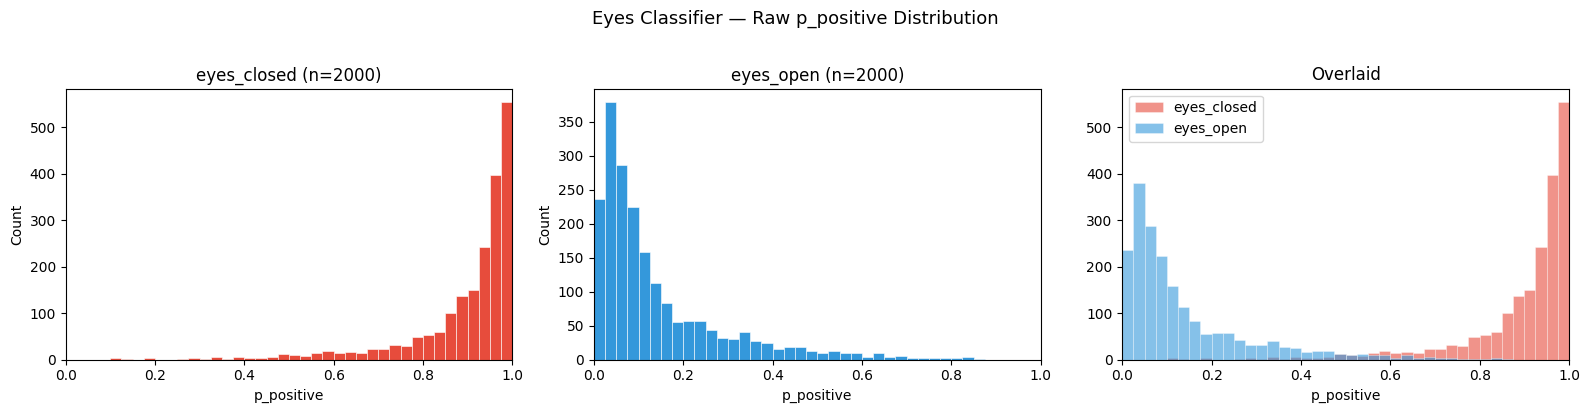

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

colors = {0: "#e74c3c", 1: "#3498db"}
bins = np.linspace(0, 1, 41)

# Per-class histograms
for label, name in CLASS_LABELS.items():
    mask = true_labels_all == label
    axes[label].hist(p_positive_all[mask], bins=bins, color=colors[label], edgecolor="white", linewidth=0.4)
    axes[label].set_title(f"{name} (n={mask.sum()})")
    axes[label].set_xlabel("p_positive")
    axes[label].set_ylabel("Count")
    axes[label].set_xlim(0, 1)

# Overlaid
for label, name in CLASS_LABELS.items():
    mask = true_labels_all == label
    axes[2].hist(p_positive_all[mask], bins=bins, color=colors[label], alpha=0.6, edgecolor="white", linewidth=0.4, label=name)
axes[2].set_title("Overlaid")
axes[2].set_xlabel("p_positive")
axes[2].set_xlim(0, 1)
axes[2].legend()

plt.suptitle("Eyes Classifier — Raw p_positive Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Apply ThresholdPredictor

In [5]:
predictor = ThresholdPredictor("eyes")
print(f"Thresholds — low={predictor.config.low}  high={predictor.config.high}")
print(f"Intermediate maps to: {predictor.intermediate_class}")

p_tensor = torch.tensor(np.stack([p_positive_all, 1 - p_positive_all], axis=1))
# ThresholdPredictor expects logits; pass pre-softmax equivalent via log
logits_proxy = torch.log(p_tensor.clamp(min=1e-7))
pred_labels, masks = predictor.predict(logits_proxy)

pred_array = np.array(pred_labels)
for lbl in ["positive", "intermediate", "negative"]:
    count = (pred_array == lbl).sum()
    pct   = 100 * count / len(pred_array)
    print(f"  {lbl:<14} {count:>5}  ({pct:.1f}%)")

Thresholds — low=0.15  high=0.85
Intermediate maps to: eyes_partially_closed
  positive        1583  (39.6%)
  intermediate    1012  (25.3%)
  negative        1405  (35.1%)


## Distribution 2 — ThresholdPredictor label breakdown

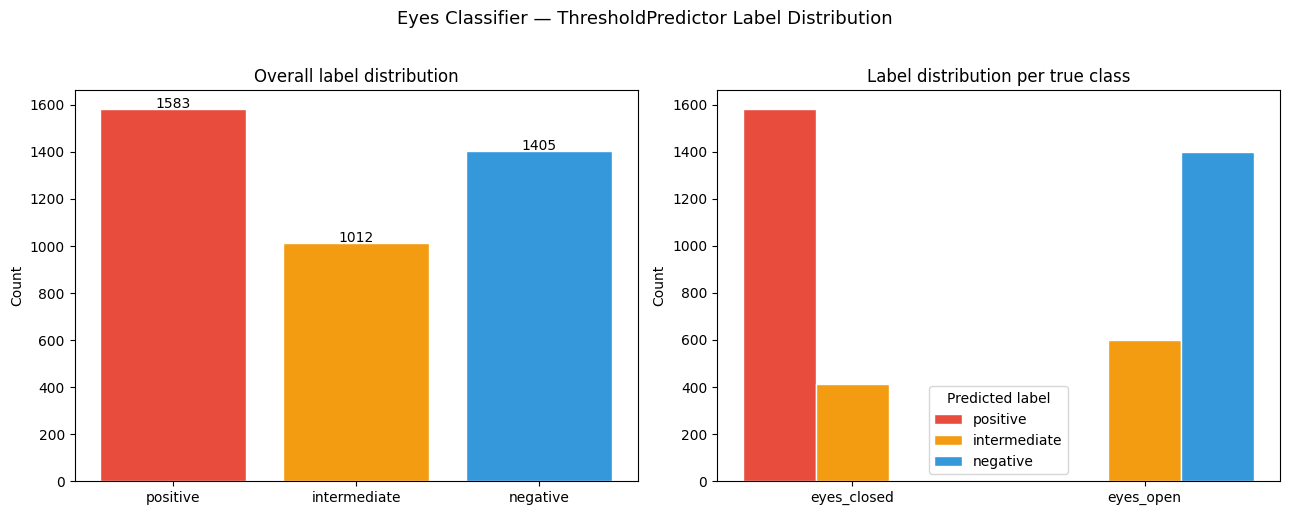

In [6]:
threshold_labels = ["positive", "intermediate", "negative"]
bar_colors = {"positive": "#e74c3c", "intermediate": "#f39c12", "negative": "#3498db"}

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Overall counts
overall_counts = [(pred_array == lbl).sum() for lbl in threshold_labels]
axes[0].bar(threshold_labels, overall_counts, color=[bar_colors[l] for l in threshold_labels], edgecolor="white")
for i, cnt in enumerate(overall_counts):
    axes[0].text(i, cnt + 5, str(cnt), ha="center", fontsize=10)
axes[0].set_title("Overall label distribution")
axes[0].set_ylabel("Count")

# Per-class breakdown
x = np.arange(len(CLASS_LABELS))
width = 0.25
for i, lbl in enumerate(threshold_labels):
    counts = [
        ((pred_array == lbl) & (true_labels_all == cls)).sum()
        for cls in CLASS_LABELS
    ]
    offset = (i - 1) * width
    bars = axes[1].bar(x + offset, counts, width, label=lbl, color=bar_colors[lbl], edgecolor="white")

axes[1].set_title("Label distribution per true class")
axes[1].set_xticks(x)
axes[1].set_xticklabels([CLASS_LABELS[c] for c in CLASS_LABELS])
axes[1].set_ylabel("Count")
axes[1].legend(title="Predicted label")

plt.suptitle("Eyes Classifier — ThresholdPredictor Label Distribution", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()